# M11 Adaptive Vector-Gated Static–Dynamic Message-Passing GNN

This notebook preserves the original data preprocessing and replaces the model
with an upgraded form of the proposed M11 architecture. The two global scalar
weights in M11 are replaced by separate **GMU-style, feature-wise, input-dependent
gates** for self-information and neighbor messages.


## Reproducibility status

The source in this notebook has been standardized for the publication comparison. Existing saved outputs are retained as historical evidence, but they must not be combined with the updated source. Run the notebook from a clean kernel; final test metrics and explanations are valid only after the standardized best-validation checkpoint is reloaded.

The active protocol is chronological and transductive. The optional unseen-node wrapper is disabled. Case-level correlation p-values in retained historical outputs are descriptive because node-window rows are temporally clustered; publication inference must use the time-cluster bootstrap intervals and matched-seed variation. Frozen zero-input modality evaluations are ablations, not independently trained unimodal baselines.


## Architecture

The model retains the defining M11 separation between self fusion and neighbor-message
fusion. For source node $j$ at time window $t$:

$$
\mathbf{z}^{N}_{j,t}=\sigma\left(W_g^N
[\mathbf{s}^{N}_{j}\Vert\mathbf{d}^{N}_{j,t}]+b_g^N\right),
$$

$$
\mathbf{m}_{j\rightarrow i,t}=\mathbf{z}^{N}_{j,t}\odot\mathbf{s}^{N}_{j}
+(1-\mathbf{z}^{N}_{j,t})\odot\mathbf{d}^{N}_{j,t}.
$$

For the target node's own information:

$$
\mathbf{z}^{S}_{i,t}=\sigma\left(W_g^S
[\mathbf{s}^{S}_{i}\Vert\mathbf{d}^{S}_{i,t}]+b_g^S\right),
$$

$$
\mathbf{e}^{S}_{i,t}=\mathbf{z}^{S}_{i,t}\odot\mathbf{s}^{S}_{i}
+(1-\mathbf{z}^{S}_{i,t})\odot\mathbf{d}^{S}_{i,t}.
$$

Incoming messages are summed, concatenated with the gated self-representation,
and passed to the update MLP. Gate values near 1 favor static information; values
near 0 favor dynamic information.


## What remains unchanged

- Original data loading and feature extraction
- Exponential smoothing and log transformation
- Train-only normalization
- Sliding-window construction and supplied splits
- Optimizer, loss family, evaluation metrics, and downstream plot types

Only the model and gate-specific analyses differ from the GMU-GNN notebook.


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader as PyGDataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 250

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'M11_Gate_only_Explainability_normalized_100_epoch'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
# model_used is standardized below.

# output_folder is standardized below.


# Publication-comparison standardization (source update; rerun required).
model_used = 'M11_Gate_Vector_only_Explainability'
# model_used is standardized below.
results_root = os.path.join("results", model_used)
checkpoint_dir = os.path.join(results_root, "checkpoints")
plot_dir = os.path.join(results_root, "plots")
csv_dir = os.path.join(results_root, "csv")
for directory in (results_root, checkpoint_dir, plot_dir, csv_dir):
    os.makedirs(directory, exist_ok=True)

# Backward-compatible destination for existing analysis cells.
output_folder = os.path.join("results_new", model_used)
os.makedirs(output_folder, exist_ok=True)
# output_folder is standardized below.
execution_status = "SOURCE_UPDATED_REQUIRES_CLEAN_RERUN"
split_type = "chronological_transductive"
prediction_horizon = 1
validation_fraction = 0.20
max_epochs = 250
patience = 20
min_delta = 1e-7
batch_size = 1
comparison_seeds = [42, 43, 44, 45, 46]

def standardized_checkpoint(
    model, optimizer, best_epoch, best_validation_loss,
    train_loss_history, validation_loss_history,
    best_model_state=None, best_optimizer_state=None,
    diagnostic_histories=None,
):
    """Build the common, reloadable comparison checkpoint."""
    import torch_geometric
    model_state = best_model_state if best_model_state is not None else model.state_dict()
    optimizer_state_matches_best_epoch = best_optimizer_state is not None
    optimizer_state = (
        best_optimizer_state if best_optimizer_state is not None
        else optimizer.state_dict()
    )
    static_names = list(static_dt.columns) if "static_dt" in globals() else []
    dynamic_names = list(dynamic_cols) if "dynamic_cols" in globals() else []
    train_at_best = None
    if best_epoch and len(train_loss_history) >= best_epoch:
        train_at_best = float(train_loss_history[best_epoch - 1])
    return {
        "schema_version": 1,
        "model_name": model_used,
        "architecture_name": type(model).__name__,
        "model_class": type(model).__name__,
        "model_config": {
            "static_dim": int(static_tensor.shape[1]),
            "dynamic_dim": int(W),
            "window_size": int(W),
            "prediction_horizon": int(prediction_horizon),
        },
        "model_state_dict": model_state,
        "optimizer_name": type(optimizer).__name__,
        "optimizer_config": {
            "lr": float(optimizer.param_groups[0]["lr"]),
            "weight_decay": float(optimizer.param_groups[0].get("weight_decay", 0.0)),
        },
        "optimizer_state_dict": optimizer_state,
        "optimizer_state_matches_best_epoch": optimizer_state_matches_best_epoch,
        "best_epoch": int(best_epoch),
        "best_validation_loss": float(best_validation_loss),
        "train_loss_at_best_epoch": train_at_best,
        "train_loss_history": list(train_loss_history),
        "validation_loss_history": list(validation_loss_history),
        "diagnostic_histories": diagnostic_histories or {},
        "seed": int(seed),
        "dataset_path": str(name_file_dataset),
        "edge_path": "datasets/aristas_subgrafoSPdaily.csv",
        "static_feature_names": static_names,
        "dynamic_column_names": dynamic_names,
        "static_dim": int(static_tensor.shape[1]),
        "dynamic_dim": int(W),
        "window_size": int(W),
        "prediction_horizon": int(prediction_horizon),
        "preprocessing_config": {
            "smoothing": "EWM",
            "ewm_alpha": 0.1,
            "transform": "log1p",
            "missing_values": "torch.nan_to_num(nan=0.0)",
            "static_scaler": "MinMaxScaler_fit_on_training_nodes",
            "dynamic_scaler": "global_minmax_fit_on_training_nodes_and_training_times",
        },
        "split_config": {
            "type": split_type,
            "train_end": int(TRAIN_END),
            "validation_fraction": float(validation_fraction),
            "fit_windows": len(fit_dataset),
            "validation_windows": len(validation_dataset),
            "test_windows": len(test_dataset),
        },
        "train_node_ids": train_nodes.detach().cpu(),
        "test_node_ids": test_nodes.detach().cpu(),
        "parameter_count": int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
        "pytorch_version": torch.__version__,
        "pyg_version": torch_geometric.__version__,
        "execution_status": execution_status,
    }



# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = sorted([col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)])
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [12]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [13]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [14]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )



# Optional unseen-node inductive workflow (disabled)

In [15]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.original_node_ids = old_node_ids.clone()  # preserve global identity
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [16]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [17]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [18]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [20]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)
# Active protocol: chronological and transductive. The optional
# InductiveWrapperDataset is intentionally not applied here.
split_type = "chronological_transductive"


# Active chronological transductive split

In [21]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [22]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [23]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# Adaptive vector-gated M11 message-passing layer

Unlike GMU-GNN, fusion is performed separately inside `message()` and `update()`.
The neighbor gate is source-node/time dependent and shared across that source
node's outgoing edges. It is not receiver-specific edge attention.


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing


class AdaptiveVectorGatedStaticDynamicGNN(MessagePassing):
    """M11 with feature-wise gates and separately normalized modality branches."""

    def __init__(
        self,
        in_static,
        window_size,
        hidden_dim=64,
        out_dim=1,
        dropout=0.2
    ):
        super().__init__(aggr="add")
        self.hidden_dim = hidden_dim

        # Separate projections preserve M11's self/neighbor distinction.
        self.lin_stat_self = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_self = nn.Linear(window_size, hidden_dim)

        self.lin_stat_neigh = nn.Linear(in_static, hidden_dim)
        self.lin_dyn_neigh = nn.Linear(window_size, hidden_dim)

        # Separate normalization for each projected modality branch.
        self.norm_stat_self = nn.LayerNorm(hidden_dim)
        self.norm_dyn_self = nn.LayerNorm(hidden_dim)

        self.norm_stat_neigh = nn.LayerNorm(hidden_dim)
        self.norm_dyn_neigh = nn.LayerNorm(hidden_dim)

        # Feature-wise vector gates: [*, 2H] -> [*, H].
        self.gate_self = nn.Linear(
            2 * hidden_dim,
            hidden_dim
        )
        self.gate_neigh = nn.Linear(
            2 * hidden_dim,
            hidden_dim
        )

        # Original M11 update MLP.
        hidden_dim_2 = 64
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim_2),
            nn.ReLU(),
        )

        # Original M11 classifier.
        self.classif_mlp = nn.Sequential(
            nn.Linear(hidden_dim_2, 128),
            nn.ReLU(),
            nn.Linear(128, out_dim),
        )

        self.last_gate_self = None
        self.last_gate_neigh_edges = None

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def _neighbor_components(self, x_static, x_dynamic):
        # Project each modality independently.
        stat = self.lin_stat_neigh(x_static)
        dyn = self.lin_dyn_neigh(x_dynamic)

        # Normalize each modality independently before gate calculation
        # and before gated fusion.
        stat = self.norm_stat_neigh(stat)
        dyn = self.norm_dyn_neigh(dyn)

        gate_input = torch.cat(
            [stat, dyn],
            dim=-1
        )

        gate = torch.sigmoid(
            self.gate_neigh(gate_input)
        )

        return stat, dyn, gate

    def _self_components(self, x_static, x_dynamic):
        # Project each modality independently.
        stat = self.lin_stat_self(x_static)
        dyn = self.lin_dyn_self(x_dynamic)

        # Normalize each modality independently before gate calculation
        # and before gated fusion.
        stat = self.norm_stat_self(stat)
        dyn = self.norm_dyn_self(dyn)

        gate_input = torch.cat(
            [stat, dyn],
            dim=-1
        )

        gate = torch.sigmoid(
            self.gate_self(gate_input)
        )

        return stat, dyn, gate

    def message(self, x_static_j, x_dynamic_j):
        stat, dyn, gate = self._neighbor_components(
            x_static_j,
            x_dynamic_j
        )

        self.last_gate_neigh_edges = gate.detach()

        return (
            gate * stat
            + (1.0 - gate) * dyn
        )

    def update(self, aggr_out, x_static, x_dynamic):
        stat, dyn, gate = self._self_components(
            x_static,
            x_dynamic
        )

        self.last_gate_self = gate.detach()

        self_emb = (
            gate * stat
            + (1.0 - gate) * dyn
        )

        fused = torch.cat(
            [self_emb, aggr_out],
            dim=-1
        )

        return self.update_mlp(fused)

    def forward(
        self,
        x_static,
        x_dynamic,
        edge_index,
        return_details=False
    ):
        # Node-level gates for explainability analysis.
        _, _, neighbor_gate_nodes = self._neighbor_components(
            x_static,
            x_dynamic
        )

        _, _, self_gate_nodes = self._self_components(
            x_static,
            x_dynamic
        )

        hidden = self.propagate(
            edge_index,
            x_static=x_static,
            x_dynamic=x_dynamic,
        )

        prediction = self.classif_mlp(
            hidden
        ).squeeze(-1)

        if return_details:
            return prediction, hidden, {
                "self_gate": self_gate_nodes,
                "neighbor_gate": neighbor_gate_nodes,
            }

        return prediction, hidden


class CrimeForecastModel(nn.Module):
    def __init__(
        self,
        in_static,
        window_size,
        hidden_dim=64
    ):
        super().__init__()

        self.gnn = AdaptiveVectorGatedStaticDynamicGNN(
            in_static=in_static,
            window_size=window_size,
            hidden_dim=hidden_dim,
            out_dim=1,
        )

    def forward(
        self,
        x_static,
        x_dynamic,
        edge_index,
        return_details=False
    ):
        return self.gnn(
            x_static,
            x_dynamic,
            edge_index,
            return_details=return_details
        )

# Model initialization


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
S = static_tensor.size(1)

model = CrimeForecastModel(
    in_static=S,
    window_size=W,
    hidden_dim=64,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

train_loader = PyGDataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = PyGDataLoader(test_dataset, batch_size=1, shuffle=False)

print(model)
print("Device:", device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CrimeForecastModel(
  (gnn): AdaptiveVectorGatedStaticDynamicGNN()
)
Device: cpu
Trainable parameters: 36033


# Validation set

In [26]:
from torch.utils.data import Subset

# Chronological validation is taken only from the existing training windows.
# The untouched test_dataset is never used for checkpoint selection.
validation_fraction = 0.20
num_development_windows = len(train_dataset)
num_validation_windows = max(1, int(np.ceil(validation_fraction * num_development_windows)))
validation_start = num_development_windows - num_validation_windows

fit_dataset = Subset(train_dataset, range(0, validation_start))
validation_dataset = Subset(train_dataset, range(validation_start, num_development_windows))

train_loader = PyGDataLoader(fit_dataset, batch_size=1, shuffle=True)
validation_loader = PyGDataLoader(validation_dataset, batch_size=1, shuffle=False)
test_loader = PyGDataLoader(test_dataset, batch_size=1, shuffle=False)

print("Fit windows:", len(fit_dataset))
print("Validation windows:", len(validation_dataset))
print("Untouched test windows:", len(test_dataset))


Fit windows: 76
Validation windows: 19
Untouched test windows: 39


# Training

The model is trained for the configured fixed number of epochs because the
supplied preprocessing defines training and test datasets but no validation
dataset. The test set is not used for early stopping or model selection.


In [27]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    self_gate_sum = 0.0
    neighbor_gate_sum = 0.0
    self_gate_elements = 0
    neighbor_gate_elements = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        loss = criterion(prediction, target)
        loss.backward()
        optimizer.step()

        n = target.numel()
        total_loss += loss.item() * n
        total_nodes += n
        self_gate_sum += details["self_gate"].detach().sum().item()
        neighbor_gate_sum += details["neighbor_gate"].detach().sum().item()
        self_gate_elements += details["self_gate"].numel()
        neighbor_gate_elements += details["neighbor_gate"].numel()

    return (
        total_loss / max(total_nodes, 1),
        self_gate_sum / max(self_gate_elements, 1),
        neighbor_gate_sum / max(neighbor_gate_elements, 1),
    )



In [28]:
@torch.no_grad()
def evaluate_validation_loss(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_nodes = 0

    for data in loader:
        data = data.to(device)

        prediction, _ = model(
            data.x_static,
            data.x_dynamic,
            data.edge_index,
        )

        target = data.y.float().view_as(
            prediction
        )

        loss = criterion(
            prediction,
            target
        )

        n = target.numel()

        total_loss += loss.item() * n
        total_nodes += n

    return total_loss / max(
        total_nodes,
        1
    )

In [29]:
# LOAD-FIRST CHECKPOINT GUARD (added for analysis-only reruns)
# The standardized best-validation checkpoint is authoritative.  Training runs
# only when it is absent and ALLOW_TRAINING_IF_CHECKPOINT_MISSING is True.
ALLOW_TRAINING_IF_CHECKPOINT_MISSING = True
criterion = nn.MSELoss()
checkpoint_path = os.path.join(
    checkpoint_dir, f"{model_used}__seed-{seed}__best-val.pt"
)
checkpoint_loaded = False

if os.path.isfile(checkpoint_path):
    checkpoint_device = next(model.parameters()).device
    checkpoint = torch.load(
        checkpoint_path, map_location=checkpoint_device, weights_only=False
    )
    if "model_state_dict" not in checkpoint:
        raise KeyError(f"Checkpoint has no model_state_dict: {checkpoint_path}")
    saved_model_name = checkpoint.get("model_name")
    if saved_model_name not in (None, model_used):
        raise ValueError(
            f"Checkpoint model mismatch: expected {model_used!r}, "
            f"found {saved_model_name!r}."
        )
    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    if "optimizer_state_dict" in checkpoint:
        try:
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        except (ValueError, KeyError) as exc:
            print(f"Optimizer state not restored (analysis is unaffected): {exc}")
    model.eval()

    best_epoch = int(checkpoint.get("best_epoch", 0) or 0)
    best_validation_loss = float(
        checkpoint.get("best_validation_loss", float("nan"))
    )
    train_loss_history = list(checkpoint.get("train_loss_history", []))
    validation_loss_history = list(
        checkpoint.get("validation_loss_history", [])
    )
    # Preserve aliases used by the different notebooks' downstream plots.
    train_loss_per_epoch = train_loss_history
    validation_loss_per_epoch = validation_loss_history
    test_loss_per_epoch = validation_loss_history
    diagnostic_histories = checkpoint.get("diagnostic_histories", {}) or {}
    norm_hist = list(diagnostic_histories.get("modality_norm_history", []))
    cond_norm_hist = list(diagnostic_histories.get("conditional_norm_history", []))
    grad_hist = list(diagnostic_histories.get("gradient_history", []))
    alpha_self_history = list(diagnostic_histories.get("alpha_self_history", []))
    alpha_neigh_history = list(diagnostic_histories.get("alpha_neigh_history", []))
    self_static_gate_history = list(
        diagnostic_histories.get("self_static_gate_history", [])
    )
    neighbor_static_gate_history = list(
        diagnostic_histories.get("neighbor_static_gate_history", [])
    )
    static_gate_history = list(diagnostic_histories.get("static_gate_history", []))
    validation_static_gate_history = list(
        diagnostic_histories.get("validation_static_gate_history", [])
    )
    best_train_loss = checkpoint.get("train_loss_at_best_epoch", float("nan"))
    num_trained_epochs = len(train_loss_history)
    validation_metrics_per_epoch = [{"MSE": value} for value in validation_loss_history]
    best_state = checkpoint["model_state_dict"]
    best_model_state = checkpoint["model_state_dict"]
    best_optimizer_state = checkpoint.get("optimizer_state_dict")
    checkpoint_loaded = True
    execution_status = "LOADED_EXISTING_BEST_CHECKPOINT_NO_TRAINING"
    print(f"Loaded existing checkpoint: {checkpoint_path}")
    print(
        f"Training skipped. Best epoch: {best_epoch}; "
        f"validation MSE: {best_validation_loss:.8g}"
    )
elif not ALLOW_TRAINING_IF_CHECKPOINT_MISSING:
    raise FileNotFoundError(
        f"Checkpoint not found and training is disabled: {checkpoint_path}"
    )
else:
    print(f"No checkpoint found; training will run: {checkpoint_path}")

if not checkpoint_loaded:
    import copy
    import numpy as np
    import torch


    # --------------------------------------------------
    # Histories required by your later analyses
    # --------------------------------------------------

    train_loss_history = []

    validation_loss_history = []

    self_static_gate_history = []

    neighbor_static_gate_history = []


    # --------------------------------------------------
    # Best-checkpoint variables
    # --------------------------------------------------

    best_validation_loss = float("inf")

    best_epoch = 0

    best_model_state = None

    best_optimizer_state = None

    epochs_without_improvement = 0


    # --------------------------------------------------
    # Training
    # --------------------------------------------------

    for epoch in range(max_epochs):

        # Train only on the chronologically earlier
        # fitting windows.
        (
            train_loss,
            self_gate_mean,
            neighbor_gate_mean,
        ) = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
        )

        # Evaluate only on the chronologically later
        # validation windows.
        validation_loss = evaluate_validation_loss(
            model=model,
            loader=validation_loader,
            criterion=criterion,
            device=device,
        )

        # Preserve all variables expected by later cells.
        train_loss_history.append(
            train_loss
        )

        validation_loss_history.append(
            validation_loss
        )

        self_static_gate_history.append(
            self_gate_mean
        )

        neighbor_static_gate_history.append(
            neighbor_gate_mean
        )

        # ----------------------------------------------
        # Check for meaningful validation improvement
        # ----------------------------------------------

        if (
            validation_loss
            < best_validation_loss - min_delta
        ):
            best_validation_loss = validation_loss

            best_epoch = epoch + 1

            # Deep copy is essential. A simple assignment
            # would continue changing during later epochs.
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            best_optimizer_state = copy.deepcopy(
                optimizer.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        # ----------------------------------------------
        # Display training progress
        # ----------------------------------------------

        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
            or epoch + 1 == max_epochs
        ):
            print(
                f"Epoch {epoch + 1:03d}/{max_epochs} | "
                f"Train MSE: {train_loss:.8f} | "
                f"Validation MSE: "
                f"{validation_loss:.8f} | "
                f"Best validation MSE: "
                f"{best_validation_loss:.8f} "
                f"(epoch {best_epoch}) | "
                f"Self static: "
                f"{self_gate_mean:.4f} | "
                f"Neighbor static: "
                f"{neighbor_gate_mean:.4f} | "
                f"Patience: "
                f"{epochs_without_improvement}/"
                f"{patience}"
            )

        # ----------------------------------------------
        # Chronological-validation early stopping
        # ----------------------------------------------

        if (
            epochs_without_improvement
            >= patience
        ):
            print(
                f"\nEarly stopping at epoch "
                f"{epoch + 1}."
            )

            print(
                f"Best chronological validation "
                f"MSE: {best_validation_loss:.8f} "
                f"at epoch {best_epoch}."
            )

            break


    # --------------------------------------------------
    # Restore the checkpoint that generalized best
    # --------------------------------------------------

    if best_model_state is None:
        raise RuntimeError(
            "No valid checkpoint was created."
        )


    model.load_state_dict(
        best_model_state
    )


    # Training loss corresponding to the selected epoch.
    best_train_loss = train_loss_history[
        best_epoch - 1
    ]


    num_trained_epochs = len(
        train_loss_history
    )


    print(
        f"\nRestored model weights from "
        f"epoch {best_epoch}."
    )

    print(
        f"Training MSE at selected epoch: "
        f"{best_train_loss:.8f}"
    )

    print(
        f"Best validation MSE: "
        f"{best_validation_loss:.8f}"
    )

    print(
        f"Total completed epochs: "
        f"{num_trained_epochs}"
    )


    # Save the common comparison checkpoint after restoring the selected model.
    checkpoint_path = os.path.join(checkpoint_dir, f"{model_used}__seed-{seed}__best-val.pt")
    checkpoint = standardized_checkpoint(
        model=model,
        optimizer=optimizer,
        best_epoch=best_epoch,
        best_validation_loss=best_validation_loss,
        train_loss_history=train_loss_history,
        validation_loss_history=validation_loss_history,
        best_model_state=best_model_state,
        best_optimizer_state=globals().get("best_optimizer_state"),
        diagnostic_histories={"self_static_gate_history": self_static_gate_history, "neighbor_static_gate_history": neighbor_static_gate_history},
    )
    torch.save(checkpoint, checkpoint_path)

    # Reload from disk so every downstream result comes from the serialized best state.
    checkpoint_device = next(model.parameters()).device
    checkpoint = torch.load(checkpoint_path, map_location=checkpoint_device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    model.eval()
    assert checkpoint["best_epoch"] == best_epoch
    execution_status = "EXECUTED_FROM_STANDARDIZED_BEST_CHECKPOINT"
    print("Restored standardized best-validation checkpoint:", checkpoint_path)



Loaded existing checkpoint: results\M11_Gate_Vector_only_Explainability\checkpoints\M11_Gate_Vector_only_Explainability__seed-42__best-val.pt
Training skipped. Best epoch: 191; validation MSE: 8.3734015e-05


In [30]:
# Skip legacy post-training checkpoint work when the standardized checkpoint was loaded.
if not checkpoint_loaded:
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),

        "best_epoch": best_epoch,
        "best_train_loss": best_train_loss,
        "best_validation_loss": (
            best_validation_loss
        ),

        "num_trained_epochs": (
            num_trained_epochs
        ),

        "train_loss_history": (
            train_loss_history
        ),

        "validation_loss_history": (
            validation_loss_history
        ),

        "self_static_gate_history": (
            self_static_gate_history
        ),

        "neighbor_static_gate_history": (
            neighbor_static_gate_history
        ),
    }


    torch.save(
        checkpoint,
        "best_chronological_m11_model.pt",
    )


    print(
        "Best chronological-validation "
        "checkpoint saved."
    )
else:
    print("Legacy checkpoint step skipped; standardized checkpoint is active.")


Legacy checkpoint step skipped; standardized checkpoint is active.


In [31]:
model.eval()

metrics, preds_per_time, targets_per_time = (
    evaluate_and_collect(
        model,
        test_loader,
        device,
    )
)

print(metrics)

{'MSE': 5.5545708164572716e-05, 'RMSE': np.float64(0.007452899312654956), 'MAE': 0.00409318320453167, 'R2': 0.9808546304702759, 'huber': 2.7772854082286358e-05}


# Training and Validation Loss plot

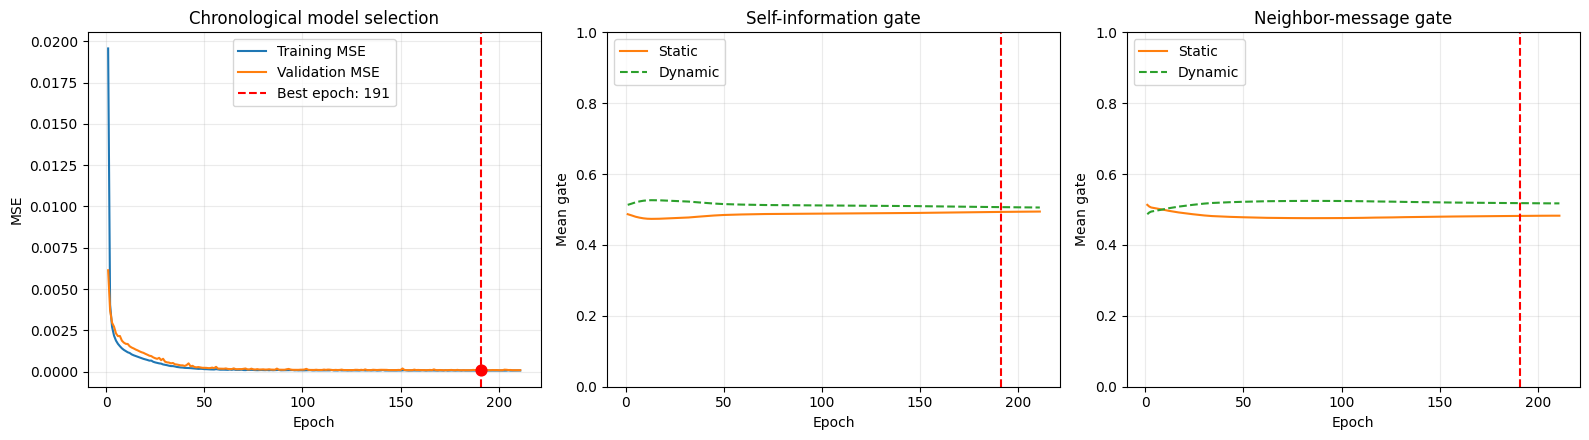

In [32]:
import matplotlib.pyplot as plt
import numpy as np


epochs = np.arange(
    1,
    num_trained_epochs + 1
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5)
)


# --------------------------------------------------
# Training and validation losses
# --------------------------------------------------

axes[0].plot(
    epochs,
    train_loss_history,
    color="tab:blue",
    label="Training MSE",
)

axes[0].plot(
    epochs,
    validation_loss_history,
    color="tab:orange",
    label="Validation MSE",
)

axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)

axes[0].scatter(
    best_epoch,
    best_validation_loss,
    color="red",
    s=60,
    zorder=5,
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title(
    "Chronological model selection"
)
axes[0].legend()
axes[0].grid(alpha=0.25)


# --------------------------------------------------
# Self modality gate
# --------------------------------------------------

axes[1].plot(
    epochs,
    self_static_gate_history,
    color="tab:orange",
    label="Static",
)

axes[1].plot(
    epochs,
    1.0 - np.asarray(
        self_static_gate_history
    ),
    color="tab:green",
    linestyle="--",
    label="Dynamic",
)

axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean gate")
axes[1].set_title(
    "Self-information gate"
)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.25)


# --------------------------------------------------
# Neighbor modality gate
# --------------------------------------------------

axes[2].plot(
    epochs,
    neighbor_static_gate_history,
    color="tab:orange",
    label="Static",
)

axes[2].plot(
    epochs,
    1.0 - np.asarray(
        neighbor_static_gate_history
    ),
    color="tab:green",
    linestyle="--",
    label="Dynamic",
)

axes[2].axvline(
    best_epoch,
    color="red",
    linestyle="--",
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean gate")
axes[2].set_title(
    "Neighbor-message gate"
)
axes[2].set_ylim(0, 1)
axes[2].legend()
axes[2].grid(alpha=0.25)


plt.tight_layout()
plt.show()

# Training and gate-history plots


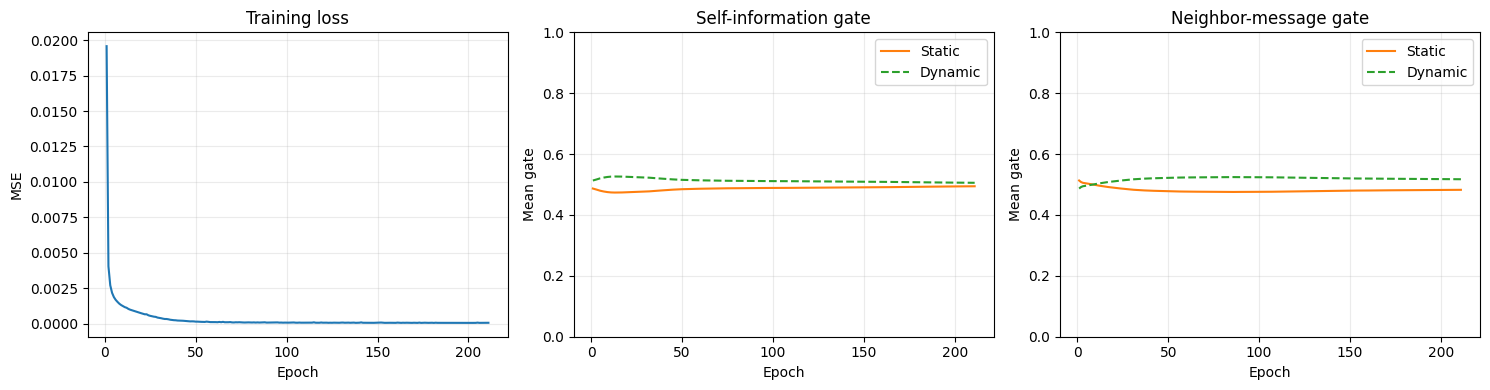

In [33]:
epochs = np.arange(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, train_loss_history, color="tab:blue")
axes[0].set(title="Training loss", xlabel="Epoch", ylabel="MSE")

axes[1].plot(epochs, self_static_gate_history, label="Static", color="tab:orange")
axes[1].plot(epochs, 1.0-np.asarray(self_static_gate_history), label="Dynamic",
             color="tab:green", linestyle="--")
axes[1].set(title="Self-information gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()

axes[2].plot(epochs, neighbor_static_gate_history, label="Static", color="tab:orange")
axes[2].plot(epochs, 1.0-np.asarray(neighbor_static_gate_history), label="Dynamic",
             color="tab:green", linestyle="--")
axes[2].set(title="Neighbor-message gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_vector_gate_training_history.png"), dpi=300, bbox_inches="tight")
plt.show()


# Test evaluation and collection


In [34]:
@torch.no_grad()
def evaluate_and_collect_m11(model, loader, device, ablation=None):
    model.eval()
    predictions_per_time, targets_per_time = [], []
    embeddings_per_time = []
    self_gates_per_time, neighbor_gates_per_time = [], []
    node_ids_per_time, time_ids_per_time = [], []

    for step, data in enumerate(loader):
        data = data.to(device)
        x_static, x_dynamic = data.x_static, data.x_dynamic
        if ablation == "static_only":
            x_dynamic = torch.zeros_like(x_dynamic)
        elif ablation == "dynamic_only":
            x_static = torch.zeros_like(x_static)

        prediction, embedding, details = model(
            x_static, x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        n = target.numel()
        node_ids = getattr(data, "node_ids", torch.arange(n, device=device)).reshape(-1)
        time_ids = getattr(data, "time_id", torch.tensor(step, device=device)).reshape(-1)
        if node_ids.numel() == 1 and n > 1:
            node_ids = node_ids.repeat(n)
        if time_ids.numel() == 1 and n > 1:
            time_ids = time_ids.repeat(n)

        predictions_per_time.append(prediction.cpu().numpy())
        targets_per_time.append(target.cpu().numpy())
        embeddings_per_time.append(embedding.cpu())
        self_gates_per_time.append(details["self_gate"].cpu())
        neighbor_gates_per_time.append(details["neighbor_gate"].cpu())
        node_ids_per_time.append(node_ids.cpu())
        time_ids_per_time.append(time_ids.cpu())

    y_pred = np.concatenate(predictions_per_time)
    y_true = np.concatenate(targets_per_time)
    error = y_pred - y_true
    mse = float(np.mean(error ** 2))
    variance = float(np.sum((y_true-y_true.mean()) ** 2))
    metrics = {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(np.mean(np.abs(error))),
        "R2": float(1.0-np.sum(error ** 2)/variance) if variance > 0 else float("nan"),
    }
    details = {
        "predictions_per_time": predictions_per_time,
        "targets_per_time": targets_per_time,
        "embeddings_per_time": embeddings_per_time,
        "self_gates": torch.cat(self_gates_per_time),
        "neighbor_gates": torch.cat(neighbor_gates_per_time),
        "node_ids": torch.cat(node_ids_per_time),
        "time_ids": torch.cat(time_ids_per_time),
    }
    return metrics, details


metrics, test_results = evaluate_and_collect_m11(model, test_loader, device)
preds_per_t = test_results["predictions_per_time"]
targets_per_t = test_results["targets_per_time"]
display(pd.DataFrame([metrics]))
pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"]).to_csv(
    os.path.join(output_folder, "metrics_M11_AdaptiveVectorGate.csv"), index=False
)


,MSE,RMSE,MAE,R2
0,0.000056,0.007453,0.004093,0.980855


# Global self and neighbor modality contributions

Each gate is feature-wise. We average over hidden dimensions for compact
node-time summaries. Gate means describe learned mixing, not causal importance.


,Role,Static gate,Dynamic gate
0,Self information,0.491365,0.508635
1,Neighbor messages,0.482685,0.517315


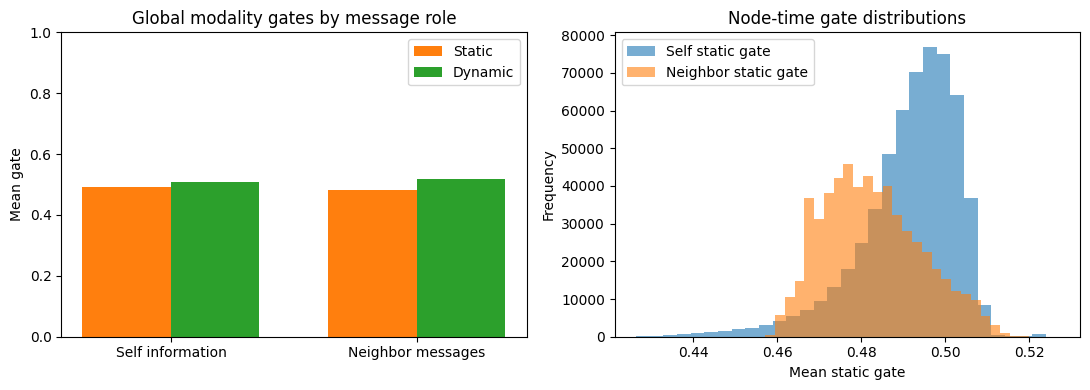

In [35]:
self_case_gate = test_results["self_gates"].mean(dim=1)
neighbor_case_gate = test_results["neighbor_gates"].mean(dim=1)

self_static = self_case_gate.mean().item()
neighbor_static = neighbor_case_gate.mean().item()

summary = pd.DataFrame({
    "Role": ["Self information", "Neighbor messages"],
    "Static gate": [self_static, neighbor_static],
    "Dynamic gate": [1.0-self_static, 1.0-neighbor_static],
})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(2)
width = 0.36
axes[0].bar(x-width/2, summary["Static gate"], width, label="Static", color="tab:orange")
axes[0].bar(x+width/2, summary["Dynamic gate"], width, label="Dynamic", color="tab:green")
axes[0].set_xticks(x, summary["Role"])
axes[0].set(title="Global modality gates by message role", ylabel="Mean gate", ylim=(0, 1))
axes[0].legend()

axes[1].hist(self_case_gate.numpy(), bins=30, alpha=0.60, label="Self static gate")
axes[1].hist(neighbor_case_gate.numpy(), bins=30, alpha=0.60, label="Neighbor static gate")
axes[1].set(title="Node-time gate distributions", xlabel="Mean static gate", ylabel="Frequency")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_global_vector_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()


# Spatial and temporal self/neighbor gate analysis


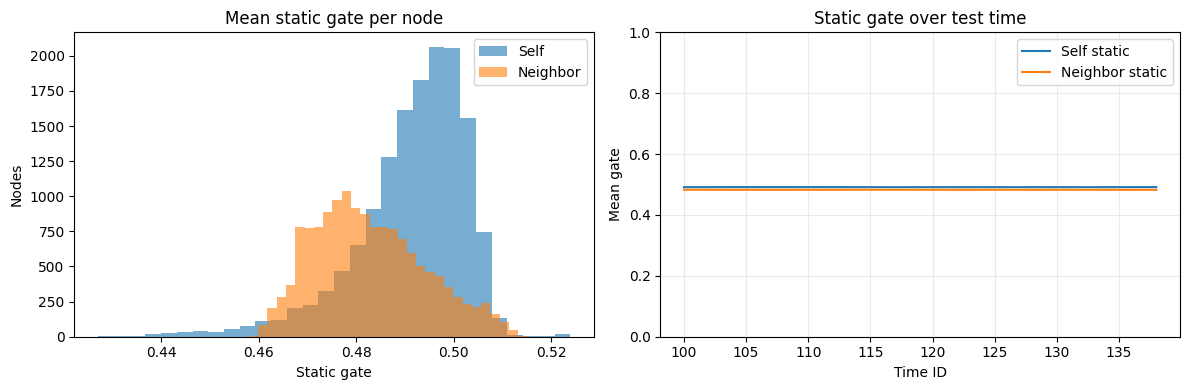

In [36]:
gate_frame = pd.DataFrame({
    "node_id": test_results["node_ids"].numpy(),
    "time_id": test_results["time_ids"].numpy(),
    "self_static_gate": self_case_gate.numpy(),
    "neighbor_static_gate": neighbor_case_gate.numpy(),
})
gate_frame["combined_static_gate"] = gate_frame[["self_static_gate", "neighbor_static_gate"]].mean(axis=1)

node_gate = gate_frame.groupby("node_id", as_index=False)[
    ["self_static_gate", "neighbor_static_gate", "combined_static_gate"]
].mean()
time_gate = gate_frame.groupby("time_id", as_index=False)[
    ["self_static_gate", "neighbor_static_gate"]
].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(node_gate["self_static_gate"], bins=30, alpha=0.6, label="Self")
axes[0].hist(node_gate["neighbor_static_gate"], bins=30, alpha=0.6, label="Neighbor")
axes[0].set(title="Mean static gate per node", xlabel="Static gate", ylabel="Nodes")
axes[0].legend()

axes[1].plot(time_gate["time_id"], time_gate["self_static_gate"], label="Self static")
axes[1].plot(time_gate["time_id"], time_gate["neighbor_static_gate"], label="Neighbor static")
axes[1].set(title="Static gate over test time", xlabel="Time ID", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_spatial_temporal_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_frame.to_csv(os.path.join(output_folder, "m11_node_time_gate_values.csv"), index=False)


# Representative dynamic-, balanced-, and static-heavy nodes


{'Dynamic-heavy': 13562, 'Balanced': 828, 'Static-heavy': 5447}


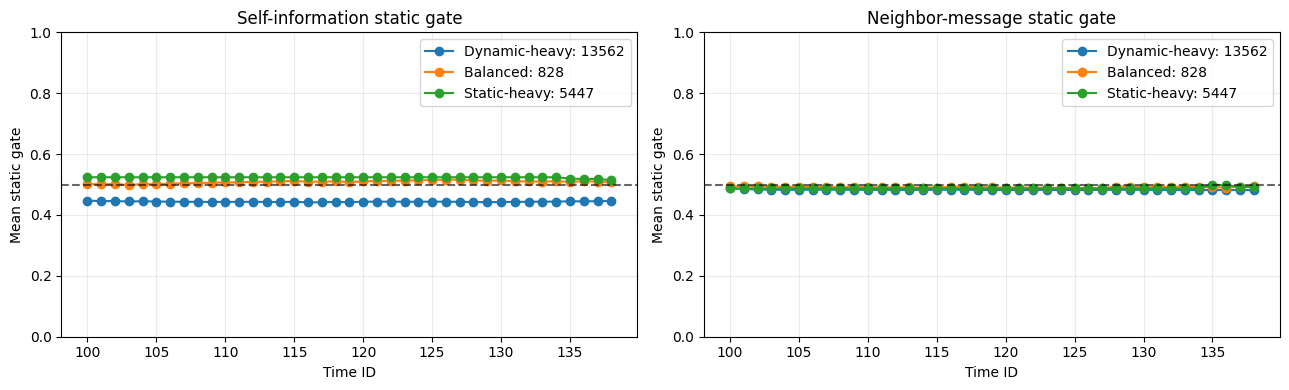

In [37]:
node_gate_sorted = node_gate.sort_values("combined_static_gate").reset_index(drop=True)
dynamic_heavy_node = int(node_gate_sorted.iloc[0]["node_id"])
balanced_idx = (node_gate_sorted["combined_static_gate"]-0.5).abs().idxmin()
balanced_node = int(node_gate_sorted.loc[balanced_idx, "node_id"])
static_heavy_node = int(node_gate_sorted.iloc[-1]["node_id"])
selected_nodes = {
    "Dynamic-heavy": dynamic_heavy_node,
    "Balanced": balanced_node,
    "Static-heavy": static_heavy_node,
}
print(selected_nodes)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for label, node in selected_nodes.items():
    series = gate_frame[gate_frame["node_id"] == node].sort_values("time_id")
    axes[0].plot(series["time_id"], series["self_static_gate"], marker="o",
                 label=f"{label}: {node}")
    axes[1].plot(series["time_id"], series["neighbor_static_gate"], marker="o",
                 label=f"{label}: {node}")
for ax, title in zip(axes, ["Self-information static gate", "Neighbor-message static gate"]):
    ax.axhline(0.5, color="black", linestyle="--", alpha=0.6)
    ax.set(title=title, xlabel="Time ID", ylabel="Mean static gate", ylim=(0, 1))
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_representative_node_gates.png"), dpi=300, bbox_inches="tight")
plt.show()


# Modality ablation

This input-ablation test evaluates the trained full model after zeroing one
modality. For a stronger comparison, separately train static-only and
dynamic-only GNN baselines as well.


,Input,MSE,RMSE,MAE,R2
0,Full model,0.000056,0.007453,0.004093,0.980855
1,Static only,0.003674,0.060617,0.028516,-0.266510
2,Dynamic only,0.000132,0.011484,0.005850,0.954541


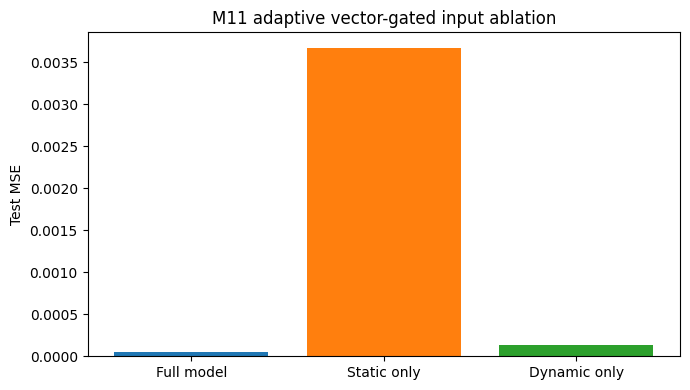

In [38]:
static_metrics, _ = evaluate_and_collect_m11(model, test_loader, device, ablation="static_only")
dynamic_metrics, _ = evaluate_and_collect_m11(model, test_loader, device, ablation="dynamic_only")
ablation_results = pd.DataFrame([
    {"Input": "Full model", **metrics},
    {"Input": "Static only", **static_metrics},
    {"Input": "Dynamic only", **dynamic_metrics},
])
display(ablation_results)
ablation_results.to_csv(os.path.join(output_folder, "m11_ablation_results.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.bar(ablation_results["Input"], ablation_results["MSE"],
        color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Test MSE")
plt.title("M11 adaptive vector-gated input ablation")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_ablation_mse.png"), dpi=300, bbox_inches="tight")
plt.show()


# Gradient sensitivity check


In [39]:
def gradient_sensitivity(model, data, device):
    model.eval()
    data = data.to(device)
    x_static = data.x_static.detach().clone().requires_grad_(True)
    x_dynamic = data.x_dynamic.detach().clone().requires_grad_(True)
    prediction, _ = model(x_static, x_dynamic, data.edge_index)
    prediction.mean().backward()
    return {
        "Static mean |gradient|": x_static.grad.abs().mean().item(),
        "Dynamic mean |gradient|": x_dynamic.grad.abs().mean().item(),
    }


gradient_results = gradient_sensitivity(model, next(iter(test_loader)), device)
display(pd.DataFrame([gradient_results]))


,Static mean |gradient|,Dynamic mean |gradient|
0,0.000001,0.000035


# Predicted time-series and neighborhood analysis


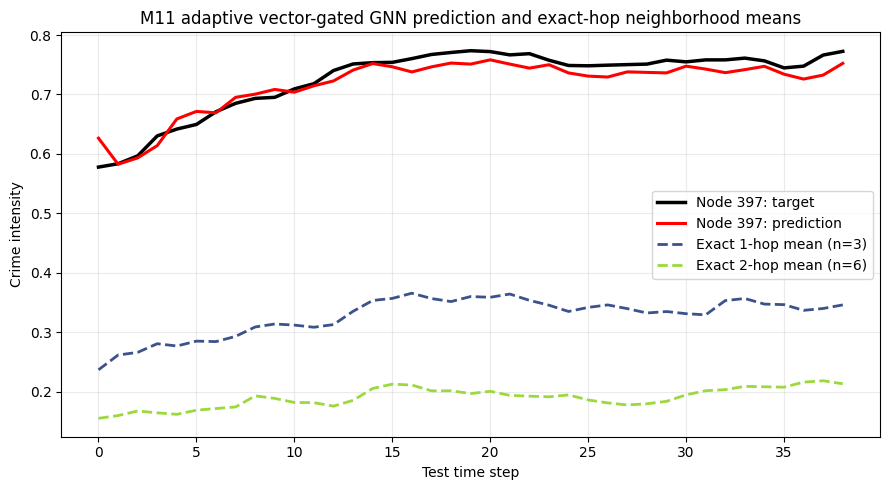

In [40]:
def adjacency_from_edge_index(edge_index, num_nodes):
    adjacency = {i: set() for i in range(num_nodes)}
    src, dst = edge_index.detach().cpu().numpy()
    for u, v in zip(src, dst):
        adjacency[int(u)].add(int(v))
        adjacency[int(v)].add(int(u))
    return adjacency


def exact_hop_nodes(center, adjacency, hop):
    visited = {center}
    frontier = {center}
    for _ in range(hop):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(adjacency.get(node, set()))
        next_frontier -= visited
        visited |= next_frontier
        frontier = next_frontier
    return sorted(frontier)


def plot_neighborhood_prediction(pred_matrix, target_matrix, center_node, adjacency,
                                 max_hop=2, output_path=None):
    time = np.arange(pred_matrix.shape[0])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(time, target_matrix[:, center_node], color="black", linewidth=2.5,
            label=f"Node {center_node}: target")
    ax.plot(time, pred_matrix[:, center_node], color="red", linewidth=2.2,
            label=f"Node {center_node}: prediction")

    colors = plt.cm.viridis(np.linspace(0.25, 0.85, max_hop))
    for hop, color in zip(range(1, max_hop + 1), colors):
        nodes = exact_hop_nodes(center_node, adjacency, hop)
        if nodes:
            mean_series = pred_matrix[:, nodes].mean(axis=1)
            ax.plot(time, mean_series, linestyle="--", linewidth=2, color=color,
                    label=f"Exact {hop}-hop mean (n={len(nodes)})")

    ax.set(xlabel="Test time step", ylabel="Crime intensity",
           title="M11 adaptive vector-gated GNN prediction and exact-hop neighborhood means")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


pred_matrix = np.stack(preds_per_t)
target_matrix = np.stack(targets_per_t)
sample_graph = test_dataset[0]
adjacency = adjacency_from_edge_index(sample_graph.edge_index, pred_matrix.shape[1])

# Select the node with the highest mean target crime in the test period.
selected_node = int(np.argmax(target_matrix.mean(axis=0)))
plot_neighborhood_prediction(
    pred_matrix, target_matrix, selected_node, adjacency, max_hop=2,
    output_path=os.path.join(output_folder, "m11_high_crime_node_neighborhood.png")
)


# Prediction scatter and residual analysis


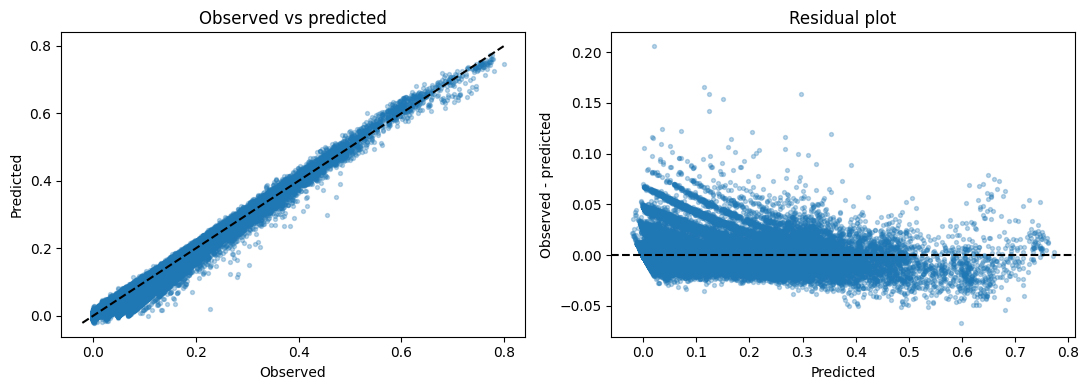

In [41]:
y_true = target_matrix.reshape(-1)
y_pred = pred_matrix.reshape(-1)
residual = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_true, y_pred, s=8, alpha=0.3)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], color="black", linestyle="--")
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(y_pred, residual, s=8, alpha=0.3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(title="Residual plot", xlabel="Predicted", ylabel="Observed - predicted")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "m11_prediction_diagnostics.png"), dpi=300, bbox_inches="tight")
plt.show()


# M11 adaptive vector-gated GNN embedding projection


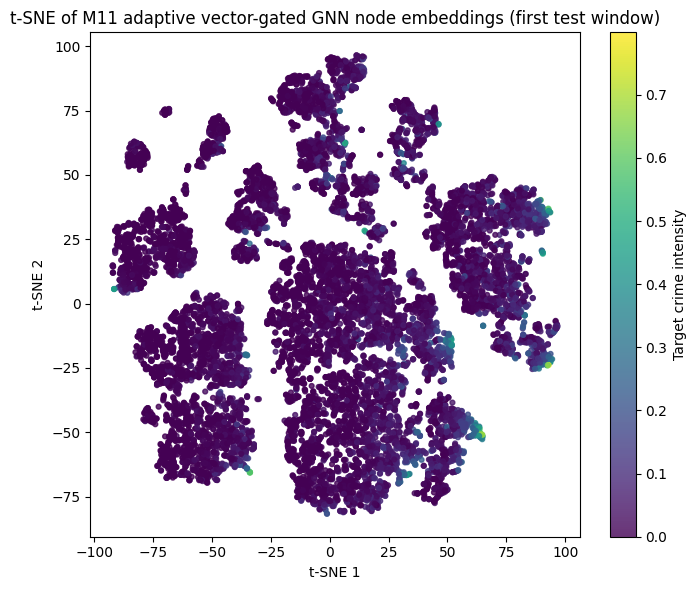

In [42]:
from sklearn.manifold import TSNE

# Use the first test window so that each plotted point corresponds to one node.
embedding = test_results["embeddings_per_time"][0].numpy()
target_first_window = targets_per_t[0]

if embedding.shape[0] >= 3:
    perplexity = min(30, max(2, (embedding.shape[0] - 1) // 3))
    embedding_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=seed,
    ).fit_transform(embedding)

    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        embedding_2d[:, 0], embedding_2d[:, 1],
        c=target_first_window, cmap="viridis", s=12, alpha=0.8
    )
    plt.colorbar(scatter, label="Target crime intensity")
    plt.title("t-SNE of M11 adaptive vector-gated GNN node embeddings (first test window)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "m11_embedding_tsne.png"), dpi=300, bbox_inches="tight")
    plt.show()

    pd.DataFrame(embedding_2d, columns=["tsne_1", "tsne_2"]).to_csv(
        os.path.join(output_folder, "m11_embedding_tsne.csv"), index=False
    )
else:
    print("At least three nodes are required for t-SNE.")


# Interpretation notes

- Self and neighbor gates are separate GMU-style feature-wise vectors.
- Their values change across nodes, time windows, and latent dimensions.
- The neighbor gate depends on the source node and time window; it is shared
  across that node's outgoing edges and is not target-specific attention.
- Gate means are learned mixing summaries, not causal importance measures.
- For comparison with GMU-GNN, keep the split, hidden dimension, training
  budget, loss, aggregation, and random seeds identical.


# Publication-oriented explainability and gate validation suite

The previous analyses are preserved unchanged. This appendix adds complementary
diagnostics that answer different questions about the proposed two-gate model.

| Analysis family | Main question | Evidence type |
|---|---|---|
| Gate distributions and entropy | Did the gates collapse or saturate? | Descriptive |
| Feature-wise specialization | Does averaging hide latent gate structure? | Descriptive |
| Gate–crime association | Does modality balance vary with crime intensity? | Associational |
| Effective activation contribution | How much gated activation enters fusion? | Mechanistic summary |
| Self-versus-neighbor comparison | Do the two message roles learn different balances? | Proposed-model specific |
| Spatial and temporal stability | Are learned patterns stable across nodes and time? | Robustness |
| Gate–error relationship | Is modality selection associated with prediction difficulty? | Diagnostic |
| Gate intervention | Does changing the learned gate harm prediction? | Faithfulness |
| Input permutation importance | Which original variables affect performance? | Model-agnostic faithfulness |
| Bootstrap confidence intervals | How uncertain are reported summaries? | Statistical uncertainty |

Gate coefficients are not automatically explanations. The strongest defense combines
gate inspection with activation magnitude, interventions, ablations, permutation
importance, and repeated-seed stability.


## A. Rich node-time explainability collection


In [ ]:
import contextlib
import math
import warnings

try:
    from scipy.stats import pearsonr, spearmanr, wilcoxon
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy is unavailable; p-values and Wilcoxon tests will be skipped.")


def _expand_case_metadata(value, n, fallback, device):
    if value is None:
        value = torch.tensor(fallback, device=device)
    value = value.reshape(-1)
    if value.numel() == 1 and n > 1:
        value = value.repeat(n)
    if value.numel() != n:
        raise ValueError(f"Metadata length {value.numel()} does not match node count {n}.")
    return value


@torch.no_grad()
def collect_rich_explainability(model, loader, device):
    # Collect gates, projections, gated activation magnitudes, errors, IDs and time.
    model.eval()
    rows = []
    self_vectors, neighbor_vectors = [], []

    for step, data in enumerate(loader):
        data = data.to(device)
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        prediction = prediction.reshape(-1)
        target = data.y.float().view_as(prediction)
        n = prediction.numel()

        node_ids = _expand_case_metadata(
            getattr(data, "node_ids", None), n, torch.arange(n, device=device), device
        )
        time_ids = _expand_case_metadata(
            getattr(data, "time_id", None), n, step, device
        )

        # These helpers reproduce the exact projections and gates used by the model.
        self_stat, self_dyn, self_gate = model.gnn._self_components(
            data.x_static, data.x_dynamic
        )
        neigh_stat, neigh_dyn, neigh_gate = model.gnn._neighbor_components(
            data.x_static, data.x_dynamic
        )

        self_static_component = self_gate * self_stat
        self_dynamic_component = (1.0 - self_gate) * self_dyn
        neigh_static_component = neigh_gate * neigh_stat
        neigh_dynamic_component = (1.0 - neigh_gate) * neigh_dyn

        self_static_mag = torch.linalg.vector_norm(self_static_component, dim=1)
        self_dynamic_mag = torch.linalg.vector_norm(self_dynamic_component, dim=1)
        neigh_static_mag = torch.linalg.vector_norm(neigh_static_component, dim=1)
        neigh_dynamic_mag = torch.linalg.vector_norm(neigh_dynamic_component, dim=1)

        eps = 1e-12
        self_static_prop = self_static_mag / (self_static_mag + self_dynamic_mag + eps)
        neigh_static_prop = neigh_static_mag / (neigh_static_mag + neigh_dynamic_mag + eps)

        batch_frame = pd.DataFrame({
            "node_id": node_ids.cpu().numpy(),
            "time_id": time_ids.cpu().numpy(),
            "input_crime": data.x_dynamic.mean(dim=1).cpu().numpy(),
            "target_crime": target.cpu().numpy(),
            "prediction": prediction.cpu().numpy(),
            "residual": (target - prediction).cpu().numpy(),
            "absolute_error": (target - prediction).abs().cpu().numpy(),
            "self_static_gate": self_gate.mean(dim=1).cpu().numpy(),
            "neighbor_static_gate": neigh_gate.mean(dim=1).cpu().numpy(),
            "self_static_activation": self_static_mag.cpu().numpy(),
            "self_dynamic_activation": self_dynamic_mag.cpu().numpy(),
            "neighbor_static_activation": neigh_static_mag.cpu().numpy(),
            "neighbor_dynamic_activation": neigh_dynamic_mag.cpu().numpy(),
            "self_static_activation_proportion": self_static_prop.cpu().numpy(),
            "neighbor_static_activation_proportion": neigh_static_prop.cpu().numpy(),
        })
        rows.append(batch_frame)
        self_vectors.append(self_gate.cpu())
        neighbor_vectors.append(neigh_gate.cpu())

    frame = pd.concat(rows, ignore_index=True)
    vectors = {
        "self": torch.cat(self_vectors).numpy(),
        "neighbor": torch.cat(neighbor_vectors).numpy(),
    }
    return frame, vectors


explain_frame, gate_vectors = collect_rich_explainability(
    model, test_loader, device
)
print("Explainability cases:", len(explain_frame))
print("Gate vector shape:", gate_vectors["self"].shape)
display(explain_frame.head())


## B. Gate health: variation, entropy and saturation

A global mean near 0.5 is not necessarily a problem. This section tests whether
individual gates vary, whether they remain uncertain around 0.5, and whether they
saturate near 0 or 1. Low variation plus no faithfulness benefit is more consistent
with gate collapse than a mean of 0.5 alone.


In [ ]:
def binary_gate_entropy(gates, eps=1e-8):
    g = np.clip(np.asarray(gates), eps, 1.0-eps)
    return -(g*np.log(g) + (1.0-g)*np.log(1.0-g)) / np.log(2.0)


def gate_health_table(gate_vectors):
    records = []
    for role, values in gate_vectors.items():
        flat = values.reshape(-1)
        case_mean = values.mean(axis=1)
        entropy = binary_gate_entropy(flat)
        records.append({
            "role": role,
            "global_mean": flat.mean(),
            "global_std": flat.std(),
            "case_mean_std": case_mean.std(),
            "q05": np.quantile(flat, 0.05),
            "median": np.median(flat),
            "q95": np.quantile(flat, 0.95),
            "minimum": flat.min(),
            "maximum": flat.max(),
            "mean_entropy_0_to_1": entropy.mean(),
            "fraction_below_0.10": np.mean(flat < 0.10),
            "fraction_above_0.90": np.mean(flat > 0.90),
            "fraction_near_balanced_0.45_0.55": np.mean((flat >= 0.45) & (flat <= 0.55)),
        })
    return pd.DataFrame(records)


gate_health = gate_health_table(gate_vectors)
display(gate_health.round(4))
gate_health.to_csv(os.path.join(output_folder, "professional_gate_health.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for role, color in [("self", "tab:blue"), ("neighbor", "tab:orange")]:
    axes[0].hist(gate_vectors[role].reshape(-1), bins=40, density=True,
                 alpha=0.45, color=color, label=role.title())
    axes[1].hist(binary_gate_entropy(gate_vectors[role]).reshape(-1), bins=40,
                 density=True, alpha=0.45, color=color, label=role.title())
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="Feature-wise gate distributions", xlabel="Static gate", ylabel="Density", xlim=(0, 1))
axes[1].set(title="Gate entropy", xlabel="Normalized binary entropy", ylabel="Density", xlim=(0, 1))
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_health.png"), dpi=300, bbox_inches="tight")
plt.show()


## C. Feature-wise specialization

The gate has shape $N\times H$. Averaging over $H$ can hide dimensions that move
in opposite directions. These plots show each latent gate dimension's mean,
variability, and association with crime.


In [ ]:
def safe_correlations(x, matrix, method="spearman"):
    x = np.asarray(x)
    values = []
    pvalues = []
    for k in range(matrix.shape[1]):
        y = matrix[:, k]
        if np.std(x) == 0 or np.std(y) == 0:
            values.append(np.nan)
            pvalues.append(np.nan)
        elif SCIPY_AVAILABLE:
            result = spearmanr(x, y) if method == "spearman" else pearsonr(x, y)
            values.append(float(result[0]))
            pvalues.append(float(result[1]))
        else:
            values.append(float(np.corrcoef(x, y)[0, 1]))
            pvalues.append(np.nan)
    return np.asarray(values), np.asarray(pvalues)


crime_values = explain_frame["input_crime"].to_numpy()
feature_records = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex="col")

for row, (role, color) in enumerate([("self", "tab:blue"), ("neighbor", "tab:orange")]):
    values = gate_vectors[role]
    means = values.mean(axis=0)
    stds = values.std(axis=0)
    rho, pval = safe_correlations(crime_values, values, method="spearman")
    dims = np.arange(values.shape[1])

    axes[row, 0].errorbar(dims, means, yerr=stds, marker="o", markersize=3,
                          linewidth=1, capsize=2, color=color)
    axes[row, 0].axhline(0.5, color="black", linestyle="--", linewidth=1)
    axes[row, 0].set(title=f"{role.title()} gate by latent dimension",
                     ylabel="Mean static gate", ylim=(0, 1))

    axes[row, 1].bar(dims, rho, color=color)
    axes[row, 1].axhline(0, color="black", linewidth=1)
    axes[row, 1].set(title=f"{role.title()} gate–crime association",
                     ylabel="Spearman rho")

    for k in dims:
        feature_records.append({
            "role": role, "dimension": int(k), "mean_gate": means[k],
            "std_gate": stds[k], "crime_spearman_rho": rho[k],
            "crime_spearman_p": pval[k],
        })

axes[1, 0].set_xlabel("Latent gate dimension")
axes[1, 1].set_xlabel("Latent gate dimension")
for ax in axes.ravel():
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_featurewise_gate_specialization.png"), dpi=300, bbox_inches="tight")
plt.show()

featurewise_gate_stats = pd.DataFrame(feature_records)
featurewise_gate_stats.to_csv(os.path.join(output_folder, "professional_featurewise_gate_stats.csv"), index=False)
display(featurewise_gate_stats.reindex(featurewise_gate_stats.crime_spearman_rho.abs().sort_values(ascending=False).index).head(10))


## D. Gate association with input and future crime

Pearson measures linear association; Spearman measures monotonic association.
Correlations are computed on all original node-time cases. Binning is used only
for visualization, preventing smoothed bin means from inflating the reported
association.


In [ ]:
def association_stats(x, y):
    x, y = np.asarray(x), np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {"pearson_r": np.nan, "pearson_p": np.nan,
                "spearman_rho": np.nan, "spearman_p": np.nan}
    if SCIPY_AVAILABLE:
        pr, sr = pearsonr(x, y), spearmanr(x, y)
        return {"pearson_r": float(pr[0]), "pearson_p": float(pr[1]),
                "spearman_rho": float(sr[0]), "spearman_p": float(sr[1])}
    return {"pearson_r": float(np.corrcoef(x, y)[0, 1]), "pearson_p": np.nan,
            "spearman_rho": np.nan, "spearman_p": np.nan}


def binned_summary(frame, x_col, y_col, bins=12):
    work = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")
    out = work.groupby("bin", observed=True).agg(
        mean_x=(x_col, "mean"), mean_y=(y_col, "mean"),
        std_y=(y_col, "std"), count=(y_col, "size")
    ).reset_index(drop=True)
    out["ci95"] = 1.96*out["std_y"] / np.sqrt(out["count"].clip(lower=1))
    return out


association_rows = []
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, gate_col in enumerate(["self_static_gate", "neighbor_static_gate"]):
    role = "Self" if gate_col.startswith("self") else "Neighbor"
    for col, x_col in enumerate(["input_crime", "target_crime"]):
        stats = association_stats(explain_frame[x_col], explain_frame[gate_col])
        association_rows.append({"role": role, "crime_variable": x_col, **stats})
        summary = binned_summary(explain_frame, x_col, gate_col, bins=12)
        ax = axes[row, col]
        ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
        ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                        summary["mean_y"]+summary["ci95"], alpha=0.2)
        ax.set(title=f"{role} static gate vs {x_col.replace('_', ' ')}",
               xlabel=x_col.replace("_", " ").title(), ylabel="Mean static gate", ylim=(0, 1))
        ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"], loc="best")
        ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_crime_associations.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_crime_associations = pd.DataFrame(association_rows)
display(gate_crime_associations.round(5))
gate_crime_associations.to_csv(os.path.join(output_folder, "professional_gate_crime_associations.csv"), index=False)


## E. Effective gated activation contribution

Gate values alone ignore the magnitude of projected modality representations.
For example, a gate of 0.5 can still yield a much larger dynamic contribution if
the dynamic projection has greater norm. The normalized activation proportions
below are therefore stronger mechanistic summaries than raw gates alone.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
contribution_rows = []

for ax, role in zip(axes, ["self", "neighbor"]):
    gate_col = f"{role}_static_gate"
    prop_col = f"{role}_static_activation_proportion"
    summary = binned_summary(explain_frame, "input_crime", prop_col, bins=12)
    ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2,
            label="Static activation proportion")
    ax.plot(summary["mean_x"], 1.0-summary["mean_y"], marker="s", linestyle="--",
            linewidth=2, label="Dynamic activation proportion")
    ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                    summary["mean_y"]+summary["ci95"], alpha=0.15)
    ax.set(title=f"{role.title()} effective contribution vs crime",
           xlabel="Mean input crime", ylabel="Normalized activation magnitude", ylim=(0, 1))
    ax.legend()
    ax.grid(alpha=0.2)
    contribution_rows.append({
        "role": role,
        "mean_raw_static_gate": explain_frame[gate_col].mean(),
        "mean_effective_static_proportion": explain_frame[prop_col].mean(),
        "mean_effective_dynamic_proportion": 1.0-explain_frame[prop_col].mean(),
        "gate_vs_effective_pearson": association_stats(explain_frame[gate_col], explain_frame[prop_col])["pearson_r"],
    })

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_effective_activation_contribution.png"), dpi=300, bbox_inches="tight")
plt.show()

effective_contribution_summary = pd.DataFrame(contribution_rows)
display(effective_contribution_summary.round(4))
effective_contribution_summary.to_csv(os.path.join(output_folder, "professional_effective_contribution.csv"), index=False)


## F. Self-versus-neighbor role separation

This is the analysis most specific to the proposed architecture. If self and
neighbor gates learn different distributions, the two-gate design captures a
distinction that a standard one-gate GMU cannot represent.


In [ ]:
self_gate_values = explain_frame["self_static_gate"].to_numpy()
neighbor_gate_values = explain_frame["neighbor_static_gate"].to_numpy()
role_difference = self_gate_values - neighbor_gate_values

role_stats = association_stats(self_gate_values, neighbor_gate_values)
role_summary = {
    "mean_self_static_gate": self_gate_values.mean(),
    "mean_neighbor_static_gate": neighbor_gate_values.mean(),
    "mean_paired_difference": role_difference.mean(),
    "paired_difference_std": role_difference.std(ddof=1),
    "cohen_dz": role_difference.mean()/(role_difference.std(ddof=1)+1e-12),
    "fraction_self_more_static": np.mean(role_difference > 0),
    "self_neighbor_pearson_r": role_stats["pearson_r"],
}
if SCIPY_AVAILABLE and np.any(role_difference != 0):
    test = wilcoxon(self_gate_values, neighbor_gate_values)
    role_summary["wilcoxon_statistic"] = float(test[0])
    role_summary["wilcoxon_p"] = float(test[1])
else:
    role_summary["wilcoxon_statistic"] = np.nan
    role_summary["wilcoxon_p"] = np.nan

display(pd.DataFrame([role_summary]).round(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
hb = axes[0].hexbin(self_gate_values, neighbor_gate_values, gridsize=35,
                    cmap="viridis", mincnt=1)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(title="Self vs neighbor static gates", xlabel="Self static gate",
            ylabel="Neighbor static gate", xlim=(0, 1), ylim=(0, 1))
fig.colorbar(hb, ax=axes[0], label="Node-time count")
axes[1].hist(role_difference, bins=40, color="tab:purple", alpha=0.8)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].axvline(role_difference.mean(), color="red", linewidth=2,
                label=f"Mean={role_difference.mean():.3f}")
axes[1].set(title="Paired role difference", xlabel="Self gate - neighbor gate", ylabel="Frequency")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_self_neighbor_role_separation.png"), dpi=300, bbox_inches="tight")
plt.show()


## G. Spatial and temporal stability


In [ ]:
node_stability = explain_frame.groupby("node_id").agg(
    self_mean=("self_static_gate", "mean"),
    self_std=("self_static_gate", "std"),
    neighbor_mean=("neighbor_static_gate", "mean"),
    neighbor_std=("neighbor_static_gate", "std"),
    mean_crime=("input_crime", "mean"),
    mean_absolute_error=("absolute_error", "mean"),
).reset_index()

time_stability = explain_frame.groupby("time_id").agg(
    self_mean=("self_static_gate", "mean"),
    self_std=("self_static_gate", "std"),
    neighbor_mean=("neighbor_static_gate", "mean"),
    neighbor_std=("neighbor_static_gate", "std"),
    mean_crime=("input_crime", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(node_stability["self_mean"], node_stability["neighbor_mean"],
                c=node_stability["mean_crime"], cmap="viridis", s=18, alpha=0.7)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(title="Spatial gate means", xlabel="Node mean self gate",
            ylabel="Node mean neighbor gate", xlim=(0, 1), ylim=(0, 1))

axes[1].hist(node_stability["self_std"].dropna(), bins=30, alpha=0.6, label="Self")
axes[1].hist(node_stability["neighbor_std"].dropna(), bins=30, alpha=0.6, label="Neighbor")
axes[1].set(title="Within-node temporal variability", xlabel="Gate standard deviation", ylabel="Nodes")
axes[1].legend()

axes[2].plot(time_stability["time_id"], time_stability["self_mean"], marker="o", label="Self")
axes[2].plot(time_stability["time_id"], time_stability["neighbor_mean"], marker="s", label="Neighbor")
axes[2].set(title="Citywide temporal gate means", xlabel="Time ID", ylabel="Static gate", ylim=(0, 1))
axes[2].legend()
axes[2].grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_spatial_temporal_gate_stability.png"), dpi=300, bbox_inches="tight")
plt.show()

node_stability.to_csv(os.path.join(output_folder, "professional_node_gate_stability.csv"), index=False)
time_stability.to_csv(os.path.join(output_folder, "professional_time_gate_stability.csv"), index=False)
display(node_stability.sort_values("self_std", ascending=False).head(10))


## H. Gate relationship with prediction error

This diagnostic tests whether certain modality balances occur on easier or harder
cases. It does not establish that a gate value causes an error, but it can reveal
failure regimes and support qualitative case selection.


In [ ]:
error_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, gate_col in zip(axes, ["self_static_gate", "neighbor_static_gate"]):
    role = "Self" if gate_col.startswith("self") else "Neighbor"
    stats = association_stats(explain_frame[gate_col], explain_frame["absolute_error"])
    error_rows.append({"role": role, **stats})
    summary = binned_summary(explain_frame, gate_col, "absolute_error", bins=10)
    ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
    ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                    summary["mean_y"]+summary["ci95"], alpha=0.2)
    ax.set(title=f"{role} gate vs prediction error",
           xlabel="Mean static gate", ylabel="Mean absolute error")
    ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"])
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_error_relationship.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_error_association = pd.DataFrame(error_rows)
display(gate_error_association.round(5))
gate_error_association.to_csv(os.path.join(output_folder, "professional_gate_error_association.csv"), index=False)


## I. Gate intervention faithfulness test

This is one of the strongest post-training explainability checks. It keeps all
trained weights fixed and intervenes only on gate logits. If learned gates are
useful, replacing them with balanced, static-heavy, dynamic-heavy, role-swapped,
or shuffled gates should generally worsen prediction. These are diagnostic
interventions, not retrained competing models.


In [ ]:
def _constant_logit_hook(probability):
    p = float(np.clip(probability, 1e-4, 1.0-1e-4))
    logit = math.log(p/(1.0-p))
    def hook(module, inputs, output):
        return torch.full_like(output, logit)
    return hook


def _shuffle_logit_hook(seed):
    counter = {"value": 0}
    def hook(module, inputs, output):
        generator = torch.Generator(device=output.device)
        generator.manual_seed(seed + counter["value"])
        counter["value"] += 1
        permutation = torch.randperm(output.shape[0], generator=generator, device=output.device)
        return output[permutation]
    return hook


@contextlib.contextmanager
def gate_intervention(model, self_probability=None, neighbor_probability=None,
                      shuffle=False, seed=42):
    handles = []
    try:
        if shuffle:
            handles.append(model.gnn.gate_self.register_forward_hook(_shuffle_logit_hook(seed)))
            handles.append(model.gnn.gate_neigh.register_forward_hook(_shuffle_logit_hook(seed+10000)))
        else:
            if self_probability is not None:
                handles.append(model.gnn.gate_self.register_forward_hook(
                    _constant_logit_hook(self_probability)))
            if neighbor_probability is not None:
                handles.append(model.gnn.gate_neigh.register_forward_hook(
                    _constant_logit_hook(neighbor_probability)))
        yield
    finally:
        for handle in handles:
            handle.remove()


def evaluate_current_model(model, loader, device):
    model.eval()
    pred_all, target_all = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            prediction, _ = model(data.x_static, data.x_dynamic, data.edge_index)
            target = data.y.float().view_as(prediction)
            pred_all.append(prediction.cpu())
            target_all.append(target.cpu())
    prediction = torch.cat(pred_all).numpy()
    target = torch.cat(target_all).numpy()
    error = prediction-target
    mse = float(np.mean(error**2))
    return {"MSE": mse, "RMSE": float(np.sqrt(mse)), "MAE": float(np.mean(np.abs(error)))}


intervention_specs = [
    ("Learned gates", None, None, False),
    ("Balanced gates (0.5, 0.5)", 0.5, 0.5, False),
    ("Static-heavy gates (0.95, 0.95)", 0.95, 0.95, False),
    ("Dynamic-heavy gates (0.05, 0.05)", 0.05, 0.05, False),
    ("Self static / neighbor dynamic", 0.95, 0.05, False),
    ("Self dynamic / neighbor static", 0.05, 0.95, False),
    ("Shuffled learned gate logits", None, None, True),
]

intervention_rows = []
for label, self_p, neighbor_p, shuffle in intervention_specs:
    with gate_intervention(model, self_p, neighbor_p, shuffle=shuffle, seed=seed):
        row = evaluate_current_model(model, test_loader, device)
    intervention_rows.append({"intervention": label, **row})

gate_interventions = pd.DataFrame(intervention_rows)
baseline_mse = gate_interventions.loc[gate_interventions.intervention == "Learned gates", "MSE"].iloc[0]
gate_interventions["delta_MSE_vs_learned"] = gate_interventions["MSE"]-baseline_mse
gate_interventions["relative_MSE_change_percent"] = 100*gate_interventions["delta_MSE_vs_learned"]/(baseline_mse+1e-12)
display(gate_interventions.round(5))

plt.figure(figsize=(11, 5))
plot_df = gate_interventions.sort_values("delta_MSE_vs_learned")
colors = ["tab:green" if x <= 0 else "tab:red" for x in plot_df["delta_MSE_vs_learned"]]
plt.barh(plot_df["intervention"], plot_df["delta_MSE_vs_learned"], color=colors, alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Change in test MSE relative to learned gates")
plt.title("Gate-intervention faithfulness")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_intervention_faithfulness.png"), dpi=300, bbox_inches="tight")
plt.show()
gate_interventions.to_csv(os.path.join(output_folder, "professional_gate_interventions.csv"), index=False)


## J. Model-agnostic input permutation importance

Permutation importance breaks one input variable's node-wise alignment while
preserving its marginal distribution. The increase in test MSE estimates how
much the trained model relies on that variable. It complements latent gate
analysis by returning to interpretable original features and temporal lags.


In [ ]:
@torch.no_grad()
def permutation_importance_by_input(model, loader, device, static_names=None,
                                    repeats=3, random_seed=42):
    model.eval()
    baseline = evaluate_current_model(model, loader, device)["MSE"]
    sample = next(iter(loader))
    static_dim = sample.x_static.shape[1]
    dynamic_dim = sample.x_dynamic.shape[1]
    if static_names is None or len(static_names) != static_dim:
        static_names = [f"static_{i}" for i in range(static_dim)]
    dynamic_names = [f"crime_lag_{dynamic_dim-i}" for i in range(dynamic_dim)]

    rows = []
    for modality, dim, names in [
        ("static", static_dim, static_names),
        ("dynamic", dynamic_dim, dynamic_names),
    ]:
        for feature_index in range(dim):
            repeated_mse = []
            for repeat in range(repeats):
                pred_all, target_all = [], []
                generator = torch.Generator(device=device)
                generator.manual_seed(random_seed + 1000*feature_index + 17*repeat + (0 if modality=="static" else 100000))
                for data in loader:
                    data = data.to(device)
                    x_static = data.x_static.clone()
                    x_dynamic = data.x_dynamic.clone()
                    n = x_static.shape[0]
                    permutation = torch.randperm(n, generator=generator, device=device)
                    if modality == "static":
                        x_static[:, feature_index] = x_static[permutation, feature_index]
                    else:
                        x_dynamic[:, feature_index] = x_dynamic[permutation, feature_index]
                    prediction, _ = model(x_static, x_dynamic, data.edge_index)
                    target = data.y.float().view_as(prediction)
                    pred_all.append(prediction.cpu())
                    target_all.append(target.cpu())
                prediction = torch.cat(pred_all).numpy()
                target = torch.cat(target_all).numpy()
                repeated_mse.append(float(np.mean((prediction-target)**2)))
            rows.append({
                "modality": modality,
                "feature": names[feature_index],
                "baseline_MSE": baseline,
                "permuted_MSE_mean": np.mean(repeated_mse),
                "permuted_MSE_std": np.std(repeated_mse, ddof=1) if repeats > 1 else 0.0,
                "delta_MSE": np.mean(repeated_mse)-baseline,
            })
    return pd.DataFrame(rows)


static_feature_names = list(static_dt.columns) if len(static_dt.columns) == S else None
permutation_importance = permutation_importance_by_input(
    model, test_loader, device, static_names=static_feature_names,
    repeats=3, random_seed=seed
)
display(permutation_importance.sort_values("delta_MSE", ascending=False).head(15))

plot_df = permutation_importance.sort_values("delta_MSE", ascending=True)
plt.figure(figsize=(10, max(5, 0.32*len(plot_df))))
colors = plot_df["modality"].map({"static": "tab:orange", "dynamic": "tab:green"})
plt.barh(plot_df["feature"], plot_df["delta_MSE"], xerr=plot_df["permuted_MSE_std"],
         color=colors, alpha=0.8, capsize=2)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Increase in test MSE after permutation")
plt.title("Input permutation importance")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_input_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
permutation_importance.to_csv(os.path.join(output_folder, "professional_input_permutation_importance.csv"), index=False)


## K. Cluster bootstrap confidence intervals

Node-time cases are not independent. This bootstrap resamples time windows as
clusters, retaining all nodes within each sampled time. It provides more defensible
uncertainty intervals for global gate summaries than treating every row as independent.


In [ ]:
def cluster_bootstrap_gate_summary(frame, cluster_col="time_id", n_bootstrap=1000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    clusters = frame[cluster_col].drop_duplicates().to_numpy()
    estimates = []
    for _ in range(n_bootstrap):
        sampled = rng.choice(clusters, size=len(clusters), replace=True)
        pieces = [frame.loc[frame[cluster_col] == cluster] for cluster in sampled]
        boot = pd.concat(pieces, ignore_index=True)
        estimates.append({
            "self_mean": boot["self_static_gate"].mean(),
            "neighbor_mean": boot["neighbor_static_gate"].mean(),
            "role_difference": (boot["self_static_gate"]-boot["neighbor_static_gate"]).mean(),
            "self_effective_static": boot["self_static_activation_proportion"].mean(),
            "neighbor_effective_static": boot["neighbor_static_activation_proportion"].mean(),
        })
    estimates = pd.DataFrame(estimates)
    records = []
    for column in estimates.columns:
        records.append({
            "quantity": column,
            "estimate": frame["self_static_gate"].mean() if column == "self_mean" else
                        frame["neighbor_static_gate"].mean() if column == "neighbor_mean" else
                        (frame["self_static_gate"]-frame["neighbor_static_gate"]).mean() if column == "role_difference" else
                        frame["self_static_activation_proportion"].mean() if column == "self_effective_static" else
                        frame["neighbor_static_activation_proportion"].mean(),
            "bootstrap_ci95_low": estimates[column].quantile(0.025),
            "bootstrap_ci95_high": estimates[column].quantile(0.975),
            "bootstrap_std": estimates[column].std(ddof=1),
        })
    return pd.DataFrame(records), estimates


bootstrap_summary, bootstrap_samples = cluster_bootstrap_gate_summary(
    explain_frame, cluster_col="time_id", n_bootstrap=1000, random_seed=seed
)
display(bootstrap_summary.round(5))
bootstrap_summary.to_csv(os.path.join(output_folder, "professional_gate_bootstrap_ci.csv"), index=False)

plt.figure(figsize=(9, 4.5))
x = np.arange(len(bootstrap_summary))
lower = bootstrap_summary["estimate"]-bootstrap_summary["bootstrap_ci95_low"]
upper = bootstrap_summary["bootstrap_ci95_high"]-bootstrap_summary["estimate"]
plt.errorbar(x, bootstrap_summary["estimate"], yerr=np.vstack([lower, upper]),
             fmt="o", capsize=5, linewidth=2)
plt.xticks(x, bootstrap_summary["quantity"], rotation=20, ha="right")
plt.ylabel("Estimated value with cluster-bootstrap 95% CI")
plt.title("Uncertainty of gate and effective-contribution summaries")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "professional_gate_bootstrap_ci.png"), dpi=300, bbox_inches="tight")
plt.show()


## L. Exportable summary for comparison with GMU and GMU-GNN

To defend the proposed model, train all three models with identical preprocessing,
splits, seeds, hidden dimension, optimizer and training budget. Compare prediction
metrics separately from explainability metrics. The proposed model has two role-specific
gates; GMU and GMU-GNN have one pre-graph gate, so compare common statistics without
claiming that the gate semantics are identical.

Recommended cross-model evidence:

1. test MSE, RMSE and MAE across multiple seeds;
2. global gate mean, variance, entropy and saturation;
3. gate–crime Spearman association;
4. effective activation proportions;
5. fixed-0.5 and shuffled-gate performance degradation;
6. static/dynamic ablation and input permutation importance;
7. only for the proposed model: self–neighbor separation and its intervention benefit.


In [ ]:
def build_model_explainability_summary(model_name, metrics, frame, gate_health,
                                       intervention_table, association_table):
    learned = intervention_table.loc[
        intervention_table["intervention"] == "Learned gates"
    ].iloc[0]
    balanced = intervention_table.loc[
        intervention_table["intervention"] == "Balanced gates (0.5, 0.5)"
    ].iloc[0]
    shuffled = intervention_table.loc[
        intervention_table["intervention"] == "Shuffled learned gate logits"
    ].iloc[0]
    self_assoc = association_table.query(
        "role == 'Self' and crime_variable == 'input_crime'"
    ).iloc[0]
    neigh_assoc = association_table.query(
        "role == 'Neighbor' and crime_variable == 'input_crime'"
    ).iloc[0]
    return pd.DataFrame([{
        "model": model_name,
        "test_MSE": metrics["MSE"],
        "test_RMSE": metrics["RMSE"],
        "test_MAE": metrics["MAE"],
        "self_gate_mean": frame["self_static_gate"].mean(),
        "neighbor_gate_mean": frame["neighbor_static_gate"].mean(),
        "self_gate_std_featurewise": gate_health.query("role == 'self'")["global_std"].iloc[0],
        "neighbor_gate_std_featurewise": gate_health.query("role == 'neighbor'")["global_std"].iloc[0],
        "self_gate_entropy": gate_health.query("role == 'self'")["mean_entropy_0_to_1"].iloc[0],
        "neighbor_gate_entropy": gate_health.query("role == 'neighbor'")["mean_entropy_0_to_1"].iloc[0],
        "self_crime_spearman": self_assoc["spearman_rho"],
        "neighbor_crime_spearman": neigh_assoc["spearman_rho"],
        "self_effective_static_proportion": frame["self_static_activation_proportion"].mean(),
        "neighbor_effective_static_proportion": frame["neighbor_static_activation_proportion"].mean(),
        "balanced_gate_delta_MSE": balanced["MSE"]-learned["MSE"],
        "shuffled_gate_delta_MSE": shuffled["MSE"]-learned["MSE"],
        "self_neighbor_mean_difference": (frame["self_static_gate"]-frame["neighbor_static_gate"]).mean(),
    }])


model_explainability_summary = build_model_explainability_summary(
    "M11 adaptive vector-gated GNN", metrics, explain_frame,
    gate_health, gate_interventions, gate_crime_associations
)
display(model_explainability_summary.T)
model_explainability_summary.to_csv(
    os.path.join(output_folder, "professional_model_explainability_summary.csv"), index=False
)


def compare_exported_model_summaries(csv_paths):
    # Load compatible one-row summary CSVs exported by each model notebook.
    tables = [pd.read_csv(path) for path in csv_paths]
    comparison = pd.concat(tables, ignore_index=True)
    display(comparison)
    return comparison


# After exporting equivalent summaries from GMU and GMU-GNN, use:
# comparison = compare_exported_model_summaries([
#     "results/GMU/professional_model_explainability_summary.csv",
#     "results/GMU_GNN/professional_model_explainability_summary.csv",
#     os.path.join(output_folder, "professional_model_explainability_summary.csv"),
# ])


## M. How to report the explainability evidence

### Strong claims supported by this notebook

- The model learns separate, input-dependent, feature-wise modality gates for
  self-information and neighbor messages.
- Gate distributions and feature-wise analyses show whether the global mean hides
  specialization.
- Effective activation proportions quantify the magnitude entering fusion rather
  than relying on coefficients alone.
- Intervention results test whether learned gate organization matters for prediction.
- Permutation importance connects latent fusion behavior back to original variables.

### Claims to avoid

- A gate is not a causal effect of a modality.
- A mean gate of 0.5 does not by itself mean equal contribution or model failure.
- Correlation between crime and a gate does not prove that crime causes modality switching.
- One trained seed is insufficient to claim stable explainability.

### Best publication protocol

Run GMU, GMU-GNN and the proposed model using at least five identical random seeds.
Report mean and standard deviation of prediction metrics and common explainability
statistics. Use the proposed model's self–neighbor separation as an additional analysis,
not as a directly equivalent GMU statistic. Treat fixed/shuffled-gate intervention,
ablation and permutation importance as the principal faithfulness evidence; use raw
gate plots as supporting descriptive evidence.


## Standard publication-comparison export

This template intentionally contains `NaN` metrics until a clean rerun supplies values from the restored checkpoint. Architecture-inapplicable fields must remain `NaN`, not fabricated.


In [ ]:
# Standard final comparison record (self-contained checkpoint reload).
checkpoint_path = os.path.join(
    checkpoint_dir, f"{model_used}__seed-{seed}__best-val.pt"
)
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(
        f"Standardized checkpoint not found: {checkpoint_path}. "
        "Run the training cell first."
    )

checkpoint_device = next(model.parameters()).device
checkpoint = torch.load(
    checkpoint_path, map_location=checkpoint_device, weights_only=False
)
model.load_state_dict(checkpoint["model_state_dict"])
if "optimizer_state_dict" in checkpoint:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.eval()
execution_status = "EXECUTED_FROM_STANDARDIZED_BEST_CHECKPOINT"

metric_candidates = [
    globals().get("metrics"),
    globals().get("scalar_metrics"),
    globals().get("hierarchical_metrics"),
    globals().get("test_metrics"),
]
final_metrics = next((m for m in metric_candidates if isinstance(m, dict)), None)
if final_metrics is None:
    raise RuntimeError("No final metric dictionary is available; run final test evaluation first.")

def _metric(name):
    for key, value in final_metrics.items():
        if str(key).lower().replace("²", "2") == name:
            return float(value)
    return np.nan

publication_comparison_summary = pd.DataFrame([{
    "model": model_used,
    "seed": seed,
    "split": split_type,
    "n_windows": len(test_dataset),
    "n_nodes": int(static_tensor.shape[0]),
    "n_cases": int(len(test_dataset) * static_tensor.shape[0]),
    "mse": _metric("mse"),
    "rmse": _metric("rmse"),
    "mae": _metric("mae"),
    "r2": _metric("r2"),
    "huber": _metric("huber"),
    "uses_graph": True,
    "execution_status": execution_status,
}])

publication_comparison_summary.to_csv(
    os.path.join(csv_dir, f"{model_used}__seed-{seed}__summary.csv"), index=False
)
display(publication_comparison_summary)
